# UTS : Sistem Informasi Geografis

## Klasifikasi Tutupan Lahan (LULC) Provinsi Jawa Timur Menggunakan Citra Sentinel-2A

## 1. Business Understanding

### 1.1 Latar Belakang

Provinsi Jawa Timur merupakan salah satu pusat pertumbuhan ekonomi dan lumbung pangan nasional. Dinamika pembangunan yang pesat memicu terjadinya konversi tutupan lahan secara masif, seperti alih fungsi lahan pertanian (sawah) menjadi area pemukiman atau industri, serta menyusutnya luasan kawasan lindung seperti hutan mangrove di pesisir.

Pemantauan perubahan tutupan lahan (*Land Use and Land Cover* / LULC) menggunakan survei lapangan konvensional memakan biaya besar, waktu yang lama, dan cakupan spasial yang terbatas. Di sisi lain, pemerintah daerah memerlukan data pemetaan yang aktual untuk mengevaluasi **Rencana Tata Ruang Wilayah (RTRW)** dan merumuskan kebijakan tata ruang yang berwawasan lingkungan. Oleh karena itu, diperlukan sebuah pendekatan otomatis berbasis Sistem Informasi Geografis (SIG) yang dipadukan dengan kecerdasan buatan (*Machine Learning*) untuk memetakan kondisi lahan secara cepat, akurat, dan luas.

### 1.2 Tujuan

Proyek analisis spasial ini memiliki beberapa tujuan utama:

1. **Otomatisasi Pemetaan Lahan:** Mengklasifikasikan 6 (enam) kelas tutupan lahan di Jawa Timur secara otomatis menggunakan data citra satelit Sentinel-2A.

2. **Evaluasi Algoritma:** Mencari dan mengimplementasikan algoritma *Machine Learning* dengan akurasi tertinggi untuk membaca pola spektral penggunaan lahan.

3. **Mendukung Kebijakan Spasial:** Menyediakan peta digital aktual yang dapat digunakan sebagai instrumen evaluasi kebijakan tata ruang dan ketahanan pangan (luasan sawah).

4. **Pengembangan Sistem Interaktif:** Men-deploy hasil pemodelan ke dalam aplikasi Web  interaktif (Streamlit) dan dokumentasi komputasi web statis (Jupyter Book) agar mudah diakses oleh para pemangku kepentingan untuk memenuhi tugas UTS matakuliah Proyek Sains Data.

## 2. Data Understanding

### 2.1 Data Collecting

Data yang digunakan dalam analisis ini bukanlah gambar biasa, melainkan data reflektansi spektral yang diekstrak dari **Citra Satelit Sentinel-2A Level-2A**. Proses akuisisi (*data collecting*) dilakukan melalui antrean komputasi *cloud* (Batch Job) di server **Copernicus Data Space Ecosystem (OpenEO)**. 
Citra yang diambil merupakan komposit nilai *median* dari rentang waktu observasi Januari 2026 hingga September 2026, yang bertujuan untuk menghilangkan gangguan noise dan tutupan awan di wilayah Jawa Timur.

### 2.2 Deskripsi Dataset dan Label Kelas

Eksperimen ini menggunakan total **300 data titik sampel koordinat** yang didistribusikan secara proporsional ke dalam 6 kelas (masing-masing 50 titik/sampel). Penentuan kelas Klasifikasi Penutup Lahan yang telah disesuaikan dengan lanskap Jawa Timur:

1. **Sawah:** Area lahan basah pertanian.

2. **Bangunan:** Area terbangun, pemukiman, dan infrastruktur padat.

3. **Lahan Hijau:** Vegetasi non-pertanian, hutan daratan, atau ruang terbuka hijau.

4. **Mangrove:** Vegetasi payau di sepanjang pesisir (utara/selatan laut Jawa Timur).

5. **Ranu (Danau):** Badan air tawar tertutup yang tersebar di wilayah Jawa Timur.

6. **Perairan Laut:** Wilayah perairan laut lepas.

Dataset dibagi dengan rasio **80:20**, yaitu 240 sampel untuk melatih (*training*) algoritma pembelajaran mesin dan 60 sampel untuk menguji (*testing*) akurasinya.

### 2.3 Ekstraksi Fitur

Dataset tabular dibentuk dari ekstraksi 7 fitur utama per piksel citra, yang terdiri dari 5 *band* spektral dan 2 indeks transformasi:

**A. Band Spektral Sentinel-2A:**

1.   **B02 (Blue - 490 nm):** Sensitif terhadap pantulan perairan dangkal dan deteksi aerosol atmosfer.

2.   **B03 (Green - 560 nm):** Menangkap puncak pantulan hijau dari klorofil dedaunan.

3.   **B04 (Red - 665 nm):** Menyerap klorofil secara kuat; parameter utama dalam mengidentifikasi tingkat kepadatan vegetasi.

4.   **B08 (NIR / Near-Infrared - 842 nm):** Sangat sensitif terhadap struktur biomassa sel daun. Memiliki nilai yang sangat tinggi pada vegetasi hijau dan diserap habis (nilai 0) pada badan air.

5.   **B11 (SWIR / Shortwave-Infrared - 1610 nm):** Digunakan secara khusus untuk mendeteksi tingkat kelembapan (kandungan air) pada permukaan tanah dan tajuk vegetasi.

**B. Indeks Transformasi (Rumus Spektral):**

Untuk mempermudah algoritma dalam mengenali pola, fitur spektral dasar dikalkulasikan ke dalam dua metrik indeks matematis:

1. **NDVI (*Normalized Difference Vegetation Index*)**
   Mengukur tingkat kehijauan, kerapatan, dan kesehatan vegetasi.
   > **Rumus:** 
   
   $$NDVI = \frac{B08 - B04}{B08 + B04}$$

2. **NDWI (*Normalized Difference Water Index*)**
   Mendeteksi fitur kebasahan dan badan air secara tegas, sembari meminimalisir efek pantulan dari tanah maupun vegetasi terrestrial.
   > **Rumus:** 
   
   $$NDWI = \frac{B03 - B08}{B03 + B08}$$

Dengan kombinasi fitur spektral dan indeks vegetasi/air ini, model *Machine Learning* dapat mengenali batasan tegas antara Sawah, Bangunan, Lahan Hijau, Mangrove, Danau, dan Perairan berdasarkan angka matematis.

### Implementasi: Instalasi Library Yang Digunakan

Sistem klasifikasi tutupan lahan ini dibangun menggunakan 5 pustaka utama Python yang saling terintegrasi:

1. **GeoPandas (`geopandas`)**
   Digunakan untuk memproses data vektor spasial, membaca titik sampel koordinat, menyelaraskan sistem referensi koordinat (CRS), dan membuat batas wilayah observasi (*Bounding Box*).

2. **OpenEO (`openeo`)**
   Berfungsi sebagai klien komputasi (*cloud*) untuk terhubung ke server *Copernicus*. Pustaka ini memproses, memfilter awan, dan mengunduh citra satelit Sentinel-2A secara otomatis tanpa membebani komputasi lokal.

3. **Rasterio (`rasterio`)**
   Spesialis pengolah data raster (citra `.tif`). Digunakan untuk membaca matriks gambar satelit dan mengekstrak nilai piksel spektral tepat pada koordinat sampel yang ditentukan oleh GeoPandas.

4. **Scikit-Learn (`sklearn`)**
   Pustaka utama untuk *Machine Learning*. Digunakan untuk membagi *dataset* (latih dan uji), melatih algoritma **Gradient Boosting Classifier**, serta menghitung metrik evaluasi akurasi model.
   
5. **Seaborn (`seaborn`)**
   Pustaka visualisasi data untuk merender hasil evaluasi statistik dan metrik model (seperti *Confusion Matrix*) ke dalam bentuk grafik atau *heatmap* yang estetik dan mudah dianalisis.

In [8]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install openeo

Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


### Implementasi : Coleccting Data

In [13]:
import geopandas as gpd
import openeo
import pandas as pd
import time  # Ditambahkan untuk memberi jeda saat mengecek status server

# 1. Membaca file data
gdf_sawah = gpd.read_file("zip://data/sawah2.zip").to_crs("EPSG:4326")
gdf_bangunan = gpd.read_file("zip://data/bangunan2.zip").to_crs("EPSG:4326")
gdf_lahan_hijau = gpd.read_file("zip://data/lahan_hijau2.zip").to_crs("EPSG:4326")
gdf_mangrove = gpd.read_file("zip://data/mangrove2.zip").to_crs("EPSG:4326")
gdf_ranu = gpd.read_file("zip://data/ranu2.zip").to_crs("EPSG:4326")
gdf_perairan_laut = gpd.read_file("zip://data/perairan_laut2.zip").to_crs("EPSG:4326")

# Memberi kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 0

gdf_bangunan["label_teks"] = "Bangunan"
gdf_bangunan["label"] = 1

gdf_lahan_hijau["label_teks"] = "Lahan Hijau"
gdf_lahan_hijau["label"] = 2

gdf_mangrove["label_teks"] = "Mangrove"
gdf_mangrove["label"] = 3

gdf_ranu["label_teks"] = "Ranu"
gdf_ranu["label"] = 4

gdf_perairan_laut["label_teks"] = "Perairan Laut"
gdf_perairan_laut["label"] = 5

# Gabungkan semuanya menjadi 1 GeoDataFrame (6 kelas x 50 = 300 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_bangunan, gdf_lahan_hijau, gdf_mangrove, gdf_ranu, gdf_perairan_laut], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah       : {len(gdf_sawah)}")
print(f"Jumlah sampel Bangunan    : {len(gdf_bangunan)}")
print(f"Jumlah sampel Lahan Hijau : {len(gdf_lahan_hijau)}")
print(f"Jumlah sampel Mangrove    : {len(gdf_mangrove)}")
print(f"Jumlah sampel Ranu        : {len(gdf_ranu)}")
print(f"Jumlah sampel Perairan Laut : {len(gdf_perairan_laut)}")
print(f"Total sampel gabungan     : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & PROSES BATCH JOB (UNTUK AREA BESAR)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-01-01", "2026-09-01"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# --- TAMBAHAN KODE: Turunkan resolusi ke ~111 meter (0.001 derajat) ---
composite_s2 = composite_s2.resample_spatial(resolution=0.001, projection=4326)

# Baru mendaftarkan antrean komputasi (Batch Job) ke server Copernicus...
job = composite_s2.create_job(
    title="UTS_Klasifikasi_S2_Jatim",
    out_format="GTiff"
)

# Mulai jalankan job di server
job.start()

# Loop untuk memantau status secara otomatis setiap 30 detik
status = job.status()
while status in ["created", "queued", "running"]:
    print(f"Status server: {status} | Menunggu proses penggabungan citra selesai...")
    time.sleep(30)
    status = job.status()

# Jika komputasi server selesai, unduh hasilnya
if status == "finished":
    print("Proses di server selesai! Mulai mengunduh citra...")
    # Akan membuat folder 'hasil_citra_uts' dan menyimpan .tif di dalamnya
    job.download_results("hasil_citra_uts")
    print("Berhasil! File GeoTIFF telah tersimpan di dalam folder 'hasil_citra_uts'.")
else:
    print(f"Proses terhenti atau gagal. Status akhir: {status}")
    # Cetak log untuk mengetahui penyebab pasti jika gagal di sisi server
    for log in job.logs():
        print(log)

Jumlah sampel Sawah       : 50
Jumlah sampel Bangunan    : 50
Jumlah sampel Lahan Hijau : 50
Jumlah sampel Mangrove    : 50
Jumlah sampel Ranu        : 50
Jumlah sampel Perairan Laut : 50
Total sampel gabungan     : 300
Bounding Box Gabungan: {'west': 111.07399620000001, 'south': -8.2676332, 'east': 113.6913416, 'north': -5.7323268}
Authenticated using refresh token.
Status server: created | Menunggu proses penggabungan citra selesai...
Status server: queued | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra selesai...
Status server: running | Menunggu proses penggabungan citra sel

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7152\3928371684.py:109: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job.download_results("hasil_citra_uts")
c:\Users\LENOVO\miniforge3\Lib\site-packages\openeo\rest\job.py:202: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
c:\Users\LENOVO\miniforge3\Lib\site-packages\openeo\rest\job.py:206: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


Berhasil! File GeoTIFF telah tersimpan di dalam folder 'hasil_citra_uts'.


In [14]:
import os

# Cek apakah file tanpa ekstensi tersebut ada, lalu tambahkan .tif
if os.path.exists("hasil_citra_uts"):
    os.rename("hasil_citra_uts", "hasil_citra_uts.tif")
    print("Selesai! File telah diubah namanya menjadi hasil_citra_uts.tif")
else:
    print("File tidak ditemukan.")

Selesai! File telah diubah namanya menjadi hasil_citra_uts.tif


In [15]:
import os
import pandas as pd
import geopandas as gpd
import rasterio

print("Memulai Data Preparation (Ekstraksi ke CSV)...")

# 1. Load Data Vektor (Shapefile/ZIP)
gdf_sawah = gpd.read_file("zip://data/sawah2.zip").to_crs("EPSG:4326")
gdf_bangunan = gpd.read_file("zip://data/bangunan2.zip").to_crs("EPSG:4326")
gdf_lahan_hijau = gpd.read_file("zip://data/lahan_hijau2.zip").to_crs("EPSG:4326")
gdf_mangrove = gpd.read_file("zip://data/mangrove2.zip").to_crs("EPSG:4326")
gdf_ranu = gpd.read_file("zip://data/ranu2.zip").to_crs("EPSG:4326")
gdf_perairan_laut = gpd.read_file("zip://data/perairan_laut2.zip").to_crs("EPSG:4326")

# 2. Beri Label Kelas
gdf_sawah["label_teks"] = "Sawah"
gdf_bangunan["label_teks"] = "Bangunan"
gdf_lahan_hijau["label_teks"] = "Lahan Hijau"
gdf_mangrove["label_teks"] = "Mangrove"
gdf_ranu["label_teks"] = "Ranu"
gdf_perairan_laut["label_teks"] = "Perairan Laut"

# Gabungkan seluruh sampel
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_bangunan, gdf_lahan_hijau, gdf_mangrove, gdf_ranu, gdf_perairan_laut], ignore_index=True), 
    crs="EPSG:4326"
)

# 3. Ekstraksi Nilai Piksel dari Citra TIF yang sudah diunduh
file_tif = "hasil_citra_uts.tif"

# (Opsional) Penyesuaian nama file jika OpenEO menyimpannya tanpa ekstensi .tif
if os.path.exists("hasil_citra_uts") and not os.path.exists(file_tif):
    os.rename("hasil_citra_uts", file_tif)

with rasterio.open(file_tif) as src:
    gdf_projected = gdf_gabungan.to_crs(src.crs)
    koordinat_sampel = [(geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry]
    nilai_band = list(src.sample(koordinat_sampel))

# 4. Susun Dataset Tabular
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# Kalkulasi Indeks Transformasi (Feature Engineering)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (df_dataset["B08"] + df_dataset["B04"] + 1e-6)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (df_dataset["B03"] + df_dataset["B08"] + 1e-6)

# Tambahkan informasi spasial dan label
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]

# 5. Simpan Hasil Akhir ke CSV
nama_csv = "dataset_uts_klasifikasi.csv"
df_dataset.to_csv(nama_csv, index=False)

print(f"✅ Data Preparation selesai! {len(df_dataset)} sampel telah diekstrak dan tersimpan di '{nama_csv}'")

Memulai Data Preparation (Ekstraksi ke CSV)...
✅ Data Preparation selesai! 300 sampel telah diekstrak dan tersimpan di 'dataset_uts_klasifikasi.csv'


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7152\296529269.py:50: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7152\296529269.py:51: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


## 4. Modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training & 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n=== INFORMASI PEMBAGIAN DATA ===")
print(f"Jumlah X_train : {X_train.shape[0]} baris, {X_train.shape[1]} kolom (fitur)")
print(f"Jumlah y_train : {y_train.shape[0]} baris")
print(f"Jumlah X_test  : {X_test.shape[0]} baris, {X_test.shape[1]} kolom (fitur)")
print(f"Jumlah y_test  : {y_test.shape[0]} baris")

# Melatih Model
model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
print("✅ Model Gradient Boosting berhasil dilatih!")


=== INFORMASI PEMBAGIAN DATA ===
Jumlah X_train : 240 baris, 7 kolom (fitur)
Jumlah y_train : 240 baris
Jumlah X_test  : 60 baris, 7 kolom (fitur)
Jumlah y_test  : 60 baris
✅ Model Gradient Boosting berhasil dilatih!


## 5. Evolution Matriks

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Prediksi data uji
y_pred = model_gb.predict(X_test)

print(f"\n✅ Akurasi Testing Gradient Boosting: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix teks
cm = confusion_matrix(y_test, y_pred, labels=model_gb.classes_)
cm_df = pd.DataFrame(
    cm, 
    index=[f"Aktual: {c}" for c in model_gb.classes_], 
    columns=[f"Prediksi: {c}" for c in model_gb.classes_]
)

print("\n=== CONFUSION MATRIX ===")
print(cm_df.to_string())

# Ekspor untuk Web (Deployment)
joblib.dump(model_gb, 'model_lulc_jatim.pkl')
print("\n✅ Berhasil mengekspor model ke 'model_lulc_jatim.pkl'")


✅ Akurasi Testing Gradient Boosting: 88.33%

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

     Bangunan       0.83      1.00      0.91        10
  Lahan Hijau       0.82      0.90      0.86        10
     Mangrove       1.00      0.70      0.82        10
Perairan Laut       0.82      0.90      0.86        10
         Ranu       0.89      0.80      0.84        10
        Sawah       1.00      1.00      1.00        10

     accuracy                           0.88        60
    macro avg       0.89      0.88      0.88        60
 weighted avg       0.89      0.88      0.88        60


=== CONFUSION MATRIX ===
                       Prediksi: Bangunan  Prediksi: Lahan Hijau  Prediksi: Mangrove  Prediksi: Perairan Laut  Prediksi: Ranu  Prediksi: Sawah
Aktual: Bangunan                       10                      0                   0                        0               0                0
Aktual: Lahan Hijau                     1                  

## 6. Deployment

Memproses prediksi jutaan piksel citra se-Jawa Timur... (Mohon tunggu)


c:\Users\LENOVO\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


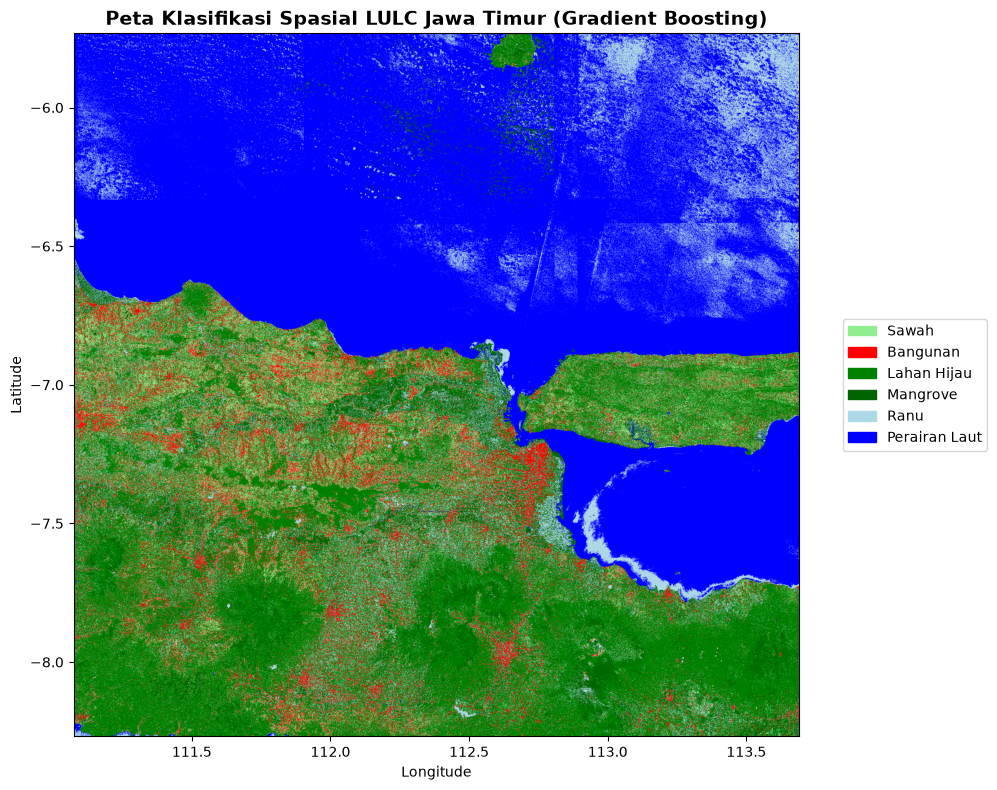

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

print("Memproses prediksi jutaan piksel citra se-Jawa Timur... (Mohon tunggu)")

with rasterio.open("hasil_citra_uts.tif") as src:
    img = src.read() 
    bounds = src.bounds

b02, b03, b04 = img[0].astype(float), img[1].astype(float), img[2].astype(float)
b08, b11 = img[3].astype(float), img[4].astype(float)

ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh array
prediksi_label = model_gb.predict(piksel_2d)

kelas_mapping = {"Sawah": 0, "Bangunan": 1, "Lahan Hijau": 2, "Mangrove": 3, "Ranu": 4, "Perairan Laut": 5}
warna_hex = ["#90EE90", "#FF0000", "#008000", "#006400", "#ADD8E6", "#0000FF"]

peta_angka = np.vectorize(kelas_mapping.get)(prediksi_label).reshape(h, w)

# Visualisasi
plt.figure(figsize=(10, 8))
cmap_6kelas = mcolors.ListedColormap(warna_hex)

plt.imshow(peta_angka, cmap=cmap_6kelas, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

patches = [mpatches.Patch(color=warna_hex[i], label=list(kelas_mapping.keys())[i]) for i in range(6)]
plt.legend(handles=patches, loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.title("Peta Klasifikasi Spasial LULC Jawa Timur (Gradient Boosting)", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_jatim.png", dpi=300, bbox_inches='tight')
plt.show()